# Goals

* new facttable (**wook.fact_amz_mkt_all_v1**)
* leakeage free modeling using 
    * lagged predictors
    * cross-sectional and time-aware
* lag of **target(`ord_rev`) included**

# Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import statsmodels.api as sm
from statsmodels.graphics.regressionplots import plot_partregress_grid
import statsmodels.formula.api as smf

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
from interpret import set_visualize_provider, show
from interpret.provider import InlineProvider
from interpret.glassbox import ExplainableBoostingRegressor

set_visualize_provider(InlineProvider())

## Utility functions

In [5]:
seed = 42

In [6]:
def plotting_predictions(ts_true,ts_pred,fig_title):
    plt.figure(figsize=(12,8))
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    
    plt.plot(ts_true,'-bo',label='Actual value')
    plt.plot(ts_pred,'-r^',label='Prediction value')
    
    plt.legend(loc='upper left',fontsize=15)
    plt.title(fig_title,fontsize=18)
    
    #rmse, mape, r2 = metrics_time_series(ts_true,ts_pred,verbose=False)
    #plt.text(.5,.96,f"RMSE : %.2f\nMAPE : %.2f\nR2  : %.2f" % (rmse,mape,r2), \
    #     bbox={'facecolor':'w','pad':5},
    #     ha="right", va="top", transform=plt.gca().transAxes,fontsize=15)
    rmse, mape, r2 = metrics_time_series(ts_true,ts_pred,verbose=False)
    plt.text(.5,.96,f"RMSE : %.2f\nMAPE : %.2f\nR2   : %.2f" % (rmse,mape,r2), \
         bbox={'facecolor':'w','pad':5},
         ha="left", va="top", transform=plt.gca().transAxes,fontsize=15)
    
    plt.show()

In [7]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def metrics_time_series(y_true, y_pred,verbose=True):
    '''
    Compute the MAE and MSE metrics from sklearn.metrics
    @param y_true: (list) list of the true values
    @param y_pred: (list) list of predicted values
    @return rmse,mape,mae: (float), (float) values of metrics RMSE,MAPE, MAE
    '''
    rmse = round(np.sqrt(mean_squared_error(y_true, y_pred)), 2) 
    
    y_true_nz = y_true[(y_true!=0.0)] # non-zero true values (See denom.)
    mape = round(np.mean(np.abs((y_true_nz - y_pred[y_true_nz.index]) / y_true_nz)) * 100,2)
    
    #mae = round(mean_absolute_error(y_true, y_pred),2)
    r2 =  round(r2_score(y_true, y_pred), 2)
    
    if verbose:
        print(f"RMSE : {rmse}")
     #  print(f"MAE : {mae}")
        print(f"MAPE : {mape}")   
        print(f"R2   : {r2}")
    return rmse,mape,r2

# Data Wrangling

import os
os.environ["GOOGLE_APPLICATION_CREDENTIALS"]="/Users/wphong/Desktop/Zinus/market-analysis-project-91130-f7b373249865.json"
import google.auth 

from google.cloud import bigquery

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

sql = """
select * from wook.fact_amz_mkt_all;
"""
--select sku_cd as sku, collection from `market-analysis-project-91130.meta.erp_sku_collection_220330`

df = bqclient.query(sql).to_dataframe()
df = df.drop_duplicates()
df

In [8]:
df = pd.read_csv('./rawdata/fact_amz_mkt_all_v1.csv')

In [9]:
df.shape

(67100, 19)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67100 entries, 0 to 67099
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   asin              67100 non-null  object 
 1   ord_rev           67100 non-null  float64
 2   ord_qty           67100 non-null  int64  
 3   sale_rank         65520 non-null  float64
 4   avg_price         60909 non-null  float64
 5   gv                67068 non-null  float64
 6   cnvrsn_rate       61839 non-null  float64
 7   date              67100 non-null  object 
 8   sku               67100 non-null  object 
 9   collection        67100 non-null  object 
 10  pdp_collection    67100 non-null  object 
 11  prdct_h1          67100 non-null  object 
 12  amz_bsr_category  67100 non-null  object 
 13  yr                67100 non-null  int64  
 14  yr_month          67100 non-null  int64  
 15  yr_wk             67100 non-null  int64  
 16  rvw_cnt           29476 non-null  float6

In [11]:
df.sku.value_counts()

SM-M-FMS-1200Q    138
WTC-CMM-1200Q     136
SC-HBSM-14Q       136
OLB-GTFM-12K      136
OLB-GTFM-12F      136
                 ... 
ZU-ABS-7XS          4
ZU-ABS-5TS          4
MSSBBT-10K          3
ZU-ABS-7CS          2
ZU-MFMAX1-10T       1
Name: sku, Length: 660, dtype: int64

In [12]:
sku_orig = df.sku.unique()
len(sku_orig)

660

## datetime handling

In [13]:
df['year_week']=[pd.to_datetime(str(yr_wk)+'0',format="%Y%U%w") for yr_wk in df.yr_wk]
df.drop(['yr_wk','yr','yr_month'],axis=1,inplace=True)

In [14]:
df.sort_values(by=['year_week','sku'],inplace=True)

In [15]:
df.reset_index(drop=True,inplace=True)

In [16]:
df.shape

(67100, 17)

## Range of date

from Jan. 2020 to Jun. 2022

In [17]:
np.min(df.year_week),np.max(df.year_week)

(Timestamp('2020-01-05 00:00:00'), Timestamp('2022-07-31 00:00:00'))

how many weeks if full records? ==> $135$ points

In [18]:
pd.date_range(start='2020-01-05',end='2022-07-31',freq='W')

DatetimeIndex(['2020-01-05', '2020-01-12', '2020-01-19', '2020-01-26',
               '2020-02-02', '2020-02-09', '2020-02-16', '2020-02-23',
               '2020-03-01', '2020-03-08',
               ...
               '2022-05-29', '2022-06-05', '2022-06-12', '2022-06-19',
               '2022-06-26', '2022-07-03', '2022-07-10', '2022-07-17',
               '2022-07-24', '2022-07-31'],
              dtype='datetime64[ns]', length=135, freq='W-SUN')

## Remove rows with no collection info or SKU info

In [19]:
df = df[~df.collection.isna()]

In [20]:
df.shape

(67100, 17)

In [21]:
sum(df.sku.isna())

0

## descriptive statistics

**`ord_rev`, `ord_qty`, `cnvrsn_rate` has negative values**

In [22]:
df.describe()

,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rvw_cnt,star12_cnt,star12_ratio
count,6.710000e+04,67100.000000,65520.000000,60909.000000,67068.000000,61839.000000,29476.000000,29476.000000,29476.000000
mean,2.238606e+04,137.369389,440.802869,189.172638,4666.199067,0.031296,3.465904,0.591464,0.180916
std,8.863938e+04,452.839693,598.452260,103.089471,11096.441428,0.124387,4.913089,1.203225,0.310760
min,-1.909576e+05,-683.000000,1.000000,-275.620000,0.000000,-1.500000,1.000000,0.000000,0.000000
25%,9.317975e+02,6.000000,97.000000,116.716364,350.000000,0.012231,1.000000,0.000000,0.000000
50%,4.865955e+03,30.000000,227.000000,169.990000,1576.000000,0.022727,2.000000,0.000000,0.000000
75%,1.706817e+04,105.000000,473.000000,242.990000,4698.000000,0.039216,4.000000,1.000000,0.250000
max,1.266026e+07,43825.000000,3994.000000,1429.460000,871072.000000,21.500000,106.000000,30.000000,1.000000


In [23]:
NA_df = dict()
cols = df.columns
for col in cols:
    NA_df[col] = sum(df[col].isna())

In [32]:
NA_df

{'asin': 0,
 'ord_rev': 0,
 'ord_qty': 0,
 'sale_rank': 1580,
 'avg_price': 6191,
 'gv': 32,
 'cnvrsn_rate': 5261,
 'date': 0,
 'sku': 0,
 'collection': 0,
 'pdp_collection': 0,
 'prdct_h1': 0,
 'amz_bsr_category': 0,
 'rvw_cnt': 37624,
 'star12_cnt': 37624,
 'star12_ratio': 37624,
 'year_week': 0}

## drop negative values

In [33]:
rows_to_drop = (df.ord_rev < 0) | (df.ord_qty <0) | (df.cnvrsn_rate <0)
sum(rows_to_drop)

450

In [34]:
neg_idx = rows_to_drop[rows_to_drop].index

In [35]:
df.loc[neg_idx]

,asin,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,date,sku,collection,pdp_collection,prdct_h1,amz_bsr_category,rvw_cnt,star12_cnt,star12_ratio,year_week
15589,B071ZTK95Q,-412.93,-7,315.0,58.990000,0.0,NaN,2020-09-12,AZ-GTFT-300SQ,GTFT,GTFT,50.TOPPERS,Mattresses Toppers,NaN,NaN,NaN,2020-09-13
15615,B071CLRK9G,-275.62,1,70.0,-275.620000,6552.0,0.000153,2020-09-12,AZ-MPRC-16K,MPRC,MPRC,20.PLATFORM BEDS,Bed Frames,8.0,1.0,0.125,2020-09-13
15622,B00GXULZY6,-656.41,-7,339.0,93.772857,0.0,NaN,2020-09-12,AZ-SB13-14F-FR,SB13,SB13,25.SMARTBASES,Bed Frames,1.0,0.0,0.000,2020-09-13
15642,B073JWM66S,-141.98,-2,187.0,70.990000,0.0,NaN,2020-09-12,AZ-SWFT-300F,SWFT,SWFT,50.TOPPERS,Mattresses Toppers,1.0,0.0,0.000,2020-09-13
15643,B073JWGN2D,-104.99,-1,95.0,104.990000,0.0,NaN,2020-09-12,AZ-SWFT-300K,SWFT,SWFT,50.TOPPERS,Mattresses Toppers,5.0,2.0,0.400,2020-09-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66431,B09HZFK9ZR,-3611.85,-14,68.0,257.989286,78.0,-0.179487,2022-07-30,ZU-MFMAMF-12Q,MFMAMF,MFMAMF,10.FOAM MATTRESSES,Mattresses,1.0,0.0,0.000,2022-07-24
66450,B09HZJBVQM,-496.92,-5,41.0,99.384000,2334.0,-0.002142,2022-07-30,ZU-MFMBHD-10T,MFMBHD,MFMBHD,10.FOAM MATTRESSES,Mattresses,1.0,0.0,0.000,2022-07-24
66984,B09XM6BPL1,-145.00,-1,NaN,145.000000,0.0,NaN,2022-08-06,ZU-ABS-7KS,ABS,OLB ABS7,30.BOX SPRINGS,Box Springs,NaN,NaN,NaN,2022-07-31
66986,B09XM77845,-85.00,-1,NaN,85.000000,0.0,NaN,2022-08-06,ZU-ABS-7TS,ABS,OLB ABS7,30.BOX SPRINGS,Box Springs,NaN,NaN,NaN,2022-07-31


In [36]:
df.drop(index=neg_idx,axis=0, inplace=True)

In [37]:
df.describe()

,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rvw_cnt,star12_cnt,star12_ratio
count,6.665000e+04,66650.000000,65151.000000,60481.000000,66619.000000,61612.000000,29358.000000,29358.000000,29358.000000
mean,2.254462e+04,138.329197,440.307363,189.125956,4695.111079,0.031701,3.470945,0.592207,0.180922
std,8.891363e+04,454.205729,598.133650,102.991307,11127.425752,0.123692,4.919950,1.204474,0.310635
min,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,9.730000e+02,6.000000,97.000000,116.700000,363.000000,0.012346,1.000000,0.000000,0.000000
50%,4.957330e+03,30.000000,227.000000,169.990000,1599.000000,0.022843,2.000000,0.000000,0.000000
75%,1.725942e+04,106.000000,473.000000,242.750455,4731.000000,0.039286,4.000000,1.000000,0.250000
max,1.266026e+07,43825.000000,3994.000000,1429.460000,871072.000000,21.500000,106.000000,30.000000,1.000000


In [38]:
len(df.sku.unique())

660

## filtering on SKUs having more than 100 samples

### drop `ord_rev`=0

In [39]:
sum(df.ord_rev==0)

6111

In [40]:
df.columns

Index(['asin', 'ord_rev', 'ord_qty', 'sale_rank', 'avg_price', 'gv',
       'cnvrsn_rate', 'date', 'sku', 'collection', 'pdp_collection',
       'prdct_h1', 'amz_bsr_category', 'rvw_cnt', 'star12_cnt', 'star12_ratio',
       'year_week'],
      dtype='object')

In [41]:
df[df.ord_rev==0][['ord_rev', 'ord_qty', 'sale_rank', 'avg_price', 'gv',
       'cnvrsn_rate','rvw_cnt', 'star12_cnt', 'star12_ratio']].describe()

,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rvw_cnt,star12_cnt,star12_ratio
count,6111.0,6111.000000,4612.000000,7.0,6080.000000,1149.000000,585.000000,585.000000,585.000000
mean,0.0,0.001309,789.631613,0.0,20.474507,0.000134,1.625641,0.268376,0.193810
std,0.0,0.040434,820.023424,0.0,141.511652,0.002437,1.647443,0.491128,0.373557
min,0.0,0.000000,1.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000
25%,0.0,0.000000,285.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000
50%,0.0,0.000000,457.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000
75%,0.0,0.000000,999.250000,0.0,0.000000,0.000000,2.000000,0.000000,0.000000
max,0.0,2.000000,3700.000000,0.0,4453.000000,0.071429,22.000000,2.000000,1.000000


In [42]:
df[~(df.ord_rev==0)].shape

(60539, 17)

In [43]:
df = df[~(df.ord_rev==0)]

### cnvrsn_rate > 1

In [44]:
sum(df.cnvrsn_rate>1)

10

In [45]:
df = df[~(df.cnvrsn_rate>1)]

In [46]:
df.shape

(60529, 17)

### Value counts

In [47]:
df['sku'].value_counts()

SM-M-FMS-1200Q    138
WTC-CMM-1200Q     136
WTC-CMM-1200F     136
OLB-GTFM-12F      136
OLB-GTFM-12K      136
                 ... 
ZU-ABS-7QS          2
ZU-ABS-5XS          2
ZU-ABS-5QS          2
ZU-ABS-5FS          2
MSSBBT-10Q          2
Name: sku, Length: 657, dtype: int64

In [48]:
sku_gt_100 = df['sku'].value_counts()[df['sku'].value_counts()>100].index.tolist()

In [49]:
print('Out of %d SKUs, filtered out more than 100 sampels : %d, %.2f percent' % \
      (len(sku_orig),len(sku_gt_100),(len(sku_gt_100)/len(sku_orig))*100))

Out of 660 SKUs, filtered out more than 100 sampels : 400, 60.61 percent


In [50]:
df_gt100 = df[df.sku.isin(sku_gt_100)].copy()

In [51]:
df_gt100.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 51891 entries, 0 to 67099
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   asin              51891 non-null  object        
 1   ord_rev           51891 non-null  float64       
 2   ord_qty           51891 non-null  int64         
 3   sale_rank         51891 non-null  float64       
 4   avg_price         51850 non-null  float64       
 5   gv                51891 non-null  float64       
 6   cnvrsn_rate       51840 non-null  float64       
 7   date              51891 non-null  object        
 8   sku               51891 non-null  object        
 9   collection        51891 non-null  object        
 10  pdp_collection    51891 non-null  object        
 11  prdct_h1          51891 non-null  object        
 12  amz_bsr_category  51891 non-null  object        
 13  rvw_cnt           27514 non-null  float64       
 14  star12_cnt        2751

## Sample counts

In [52]:
vc_sku = df_gt100[['collection','sku']].value_counts()
vc_sku

collection   sku            
FMS          SM-M-FMS-1200Q     138
CMM          WTC-CMM-1200Q      136
             WTC-CMM-1200F      136
OLB GTFM     OLB-GTFM-12K       136
             OLB-GTFM-12F       136
                               ... 
OLB SWPBBHS  OLB-SWPBBHS-12T    103
HBSM         SC-HBSM-14K        102
OLB SB13     OLB-SB13-16CK      102
FRBX         FRBX-9BG-CK        101
MSHEBT       MSHEBT-13K         101
Length: 400, dtype: int64

(array([ 11.,   8.,  12.,   8.,  15.,  13.,  11.,  42., 121., 159.]),
 array([101. , 104.7, 108.4, 112.1, 115.8, 119.5, 123.2, 126.9, 130.6,
        134.3, 138. ]),
 <BarContainer object of 10 artists>)

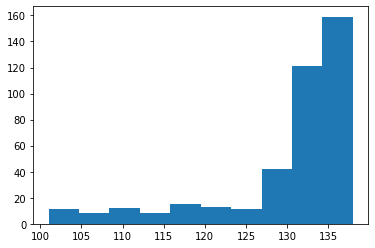

In [53]:
plt.hist(vc_sku)

In [54]:
np.min(vc_sku),np.max(vc_sku)

(101, 138)

In [55]:
df.describe()

,ord_rev,ord_qty,sale_rank,avg_price,gv,cnvrsn_rate,rvw_cnt,star12_cnt,star12_ratio
count,6.052900e+04,60529.000000,60529.000000,60464.000000,60529.000000,60453.000000,28767.000000,28767.000000,28767.000000
mean,2.482399e+04,152.313123,413.705331,189.150742,5165.442631,0.031214,3.507665,0.598846,0.180688
std,9.299747e+04,474.379476,569.074804,102.983042,11569.604927,0.037891,4.955837,1.213849,0.309249
min,3.300000e-01,0.000000,1.000000,4.648231,0.000000,0.000000,1.000000,0.000000,0.000000
25%,1.648510e+03,10.000000,93.000000,116.713603,625.000000,0.012888,1.000000,0.000000,0.000000
50%,6.293370e+03,38.000000,212.000000,169.990000,1955.000000,0.023256,2.000000,0.000000,0.000000
75%,1.964563e+04,120.000000,447.000000,242.830917,5312.000000,0.039777,4.000000,1.000000,0.250000
max,1.266026e+07,43825.000000,3994.000000,1429.460000,871072.000000,1.000000,106.000000,30.000000,1.000000


## Replacing NA

* `avg_price` : ffill
* `sale_rank` : ffill
* `cnvrsn_rate` : ffill

* `gv` : 0
* `rvw_cnt` : 0
* `star12_cnt` : 0
* `star12_ratio` : 0

### date range and filling

In [56]:
dt_rg = pd.date_range(start='2020-01-05',end='2022-07-31',freq='W')
dt_rg.name='year_week'

In [57]:
df_gt100.columns

Index(['asin', 'ord_rev', 'ord_qty', 'sale_rank', 'avg_price', 'gv',
       'cnvrsn_rate', 'date', 'sku', 'collection', 'pdp_collection',
       'prdct_h1', 'amz_bsr_category', 'rvw_cnt', 'star12_cnt', 'star12_ratio',
       'year_week'],
      dtype='object')

In [58]:
# lagging of target included!!
lag_features = ['ord_rev', 'sale_rank', 'avg_price', 'gv', 'cnvrsn_rate', 'rvw_cnt', 'star12_cnt', 'star12_ratio']

df_set_columns = ['year_week', 'sku', 'collection','pdp_collection','prdct_h1', 'amz_bsr_category',\
                  'ord_rev', 'ord_qty', 'ord_rev_lag1','sale_rank_lag1',\
                  'avg_price_lag1', 'gv_lag1', 'cnvrsn_rate_lag1',\
                  'rvw_cnt_lag1', 'star12_cnt_lag1', 'star12_ratio_lag1']
df_set = pd.DataFrame(columns=df_set_columns)

for k,sku in enumerate(sku_gt_100):
    print('Working %d/%d...' % ((k+1),len(sku_gt_100)), end='\r')
    src_df = df_gt100[df_gt100.sku==sku].set_index('year_week')
    tmp_df = pd.DataFrame(index=dt_rg)
    tmp_df = tmp_df.join(src_df)
    
    # For meaningfull ffill(), need to fill '0' first row.
    tmp_df[:1] = tmp_df[:1].fillna(0)
    
    tmp_df['sku'] = np.repeat(src_df.sku.unique(),tmp_df.shape[0])
    tmp_df['collection'] = np.repeat(src_df.collection.unique(),tmp_df.shape[0])
    tmp_df['pdp_collection'] = np.repeat(src_df.pdp_collection.unique(),tmp_df.shape[0])
    tmp_df['prdct_h1'] = np.repeat(src_df.prdct_h1.unique(),tmp_df.shape[0])
    tmp_df['amz_bsr_category'] = np.repeat(src_df.amz_bsr_category.unique(),tmp_df.shape[0])

    
    # More than 128 samples should be treated
    tmp_df_m = tmp_df.resample('W-Sun').mean() 
    #lost_cols = list(set(tmp_df.columns)-set(tmp_df_m))
    lost_cols=['sku','collection','pdp_collection','prdct_h1', 'amz_bsr_category']
    
    tmp_df_m.reset_index(inplace=True)
    tmp_df.reset_index(inplace=True)
    tmp_df_m[lost_cols] = tmp_df[lost_cols]
    
    tmp_df_m[['ord_rev', 'ord_qty']] = \
            tmp_df_m[['ord_rev', 'ord_qty']].ffill()
    tmp_df_m[['sale_rank','avg_price', 'cnvrsn_rate']] = \
            tmp_df_m[['sale_rank', 'avg_price', 'cnvrsn_rate']].ffill()
    tmp_df_m[['gv', 'rvw_cnt','star12_cnt', 'star12_ratio']] = \
            tmp_df_m[['gv', 'rvw_cnt','star12_cnt', 'star12_ratio']].fillna(0)
    
    tmp_df_m_lagged = tmp_df_m[lag_features].shift(1)
    tmp_df_m_lagged.columns = [x+'_lag1' for x in lag_features]
    tmp_df_m_lagged.fillna(0,inplace=True) # Fill 0 in first row
    
    # We should keep 'ord_rev', use lag_features[1:] to drop
    tmp_df_m.drop(lag_features[1:],axis=1,inplace=True)
    tmp_df_m = pd.concat([tmp_df_m,tmp_df_m_lagged],axis=1)
    
    df_set = df_set.append(tmp_df_m)
    del tmp_df, tmp_df_m

In [59]:
df_set

,year_week,sku,collection,pdp_collection,prdct_h1,amz_bsr_category,ord_rev,ord_qty,ord_rev_lag1,sale_rank_lag1,avg_price_lag1,gv_lag1,cnvrsn_rate_lag1,rvw_cnt_lag1,star12_cnt_lag1,star12_ratio_lag1
0,2020-01-05,SM-M-FMS-1200Q,FMS,FMS,10.FOAM MATTRESSES,Mattresses,45390.87,163.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.0,0.00
1,2020-01-12,SM-M-FMS-1200Q,FMS,FMS,10.FOAM MATTRESSES,Mattresses,45137.91,165.0,45390.87,54.0,278.471595,7509.0,0.021707,0.0,0.0,0.00
2,2020-01-19,SM-M-FMS-1200Q,FMS,FMS,10.FOAM MATTRESSES,Mattresses,41628.78,158.0,45137.91,57.0,273.563091,6683.0,0.024690,2.0,0.0,0.00
3,2020-01-26,SM-M-FMS-1200Q,FMS,FMS,10.FOAM MATTRESSES,Mattresses,42083.63,159.0,41628.78,37.0,263.473291,5965.0,0.026488,4.0,1.0,0.25
4,2020-02-02,SM-M-FMS-1200Q,FMS,FMS,10.FOAM MATTRESSES,Mattresses,5318.00,20.0,42083.63,37.0,264.676918,5576.0,0.028515,2.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,2022-07-03,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,14047.72,36.0,8455.08,103.0,469.726667,1083.0,0.016620,1.0,1.0,1.00
131,2022-07-10,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,10159.70,28.0,14047.72,67.0,390.214444,1789.0,0.020123,0.0,0.0,0.00
132,2022-07-17,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,4603.05,12.0,10159.70,89.0,362.846429,2609.0,0.010732,0.0,0.0,0.00
133,2022-07-24,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,22899.59,60.0,4603.05,116.0,383.587500,1375.0,0.008727,1.0,0.0,0.00


In [60]:
lag_features

['ord_rev',
 'sale_rank',
 'avg_price',
 'gv',
 'cnvrsn_rate',
 'rvw_cnt',
 'star12_cnt',
 'star12_ratio']

In [61]:
df_gt100.shape

(51891, 17)

In [62]:
df_set.shape

(54000, 16)

In [63]:
df_set.sku.unique()

array(['SM-M-FMS-1200Q', 'WTC-CMM-1200Q', 'WTC-CMM-1200F', 'OLB-GTFM-12F',
       'OLB-GTFM-12K', 'AZ-ASMP-10F', 'OLB-FGM-0800K', 'OLB-FGM-1000K',
       'OLB-FGM-1000F', 'OLB-FGM-0800T', 'OLB-FGM-0800F', 'OLB-FGM-1200Q',
       'OLB-CPBFW-Q', 'OLB-BNSM-6T-2PK', 'OLB-BIFD-4Q', 'OLB-ASB-T',
       'OLB-ASB-Q', 'OLB-FGM-1200F', 'OLB-GTFM-10T', 'OLB-GTFM-10K',
       'OLB-GTFM-10Q', 'OLB-ASB-K', 'OLB-GTFM-12Q', 'OLB-GTFM-12T',
       'OLB-GTFM-6K', 'OLB-GTFM-6Q', 'OLB-GTFM-8F', 'OLB-GTFM-8Q',
       'OLB-IRPBH-14F', 'OLB-IRPBH-14Q', 'OLB-ASB-NT', 'OLB-ABS-9TXL',
       'OLB-ASB-F', 'OLB-ABS-5Q', 'FSPB-F', 'FSPB-K', 'FSPB-LB-F',
       'FSPB-LB-Q', 'FSPB-Q', 'HBPBA-14Q', 'HBPBB-14F', 'M-FMS-600F',
       'OLB-ABS-5CK', 'OLB-ABS-5F', 'OLB-ABS-5K', 'OLB-ABS-5T',
       'OLB-MBBF-10F', 'OLB-ABS-7CK', 'OLB-ABS-7F', 'OLB-ABS-7K',
       'OLB-ABS-7Q', 'OLB-ABS-7T', 'OLB-ABS-7TXL', 'OLB-ABS-9CK',
       'OLB-ABS-9F', 'OLB-ABS-9K', 'OLB-ABS-9Q', 'OLB-ABS-9T',
       'OLB-IRPBHB-14Q', 'OLB-MBBF-10Q

In [64]:
df_set[['sku','year_week']].groupby('sku').agg('count')

,year_week
sku,
AZ-ASMP-10F,135
AZ-ASMP-10K,135
AZ-ASMP-10Q,135
AZ-ASMP-10T,135
AZ-ASMP-15F,135
...,...
WTC-CMM-800W,135
‎AZ-ASMPCH-15F,135
‎AZ-ASMPCH-15K,135


# Modeling (interaction terms from GA2M)

Microsoft EBM package (https://interpret.ml/docs/ebm.html)

In [65]:
features = ['ord_rev_lag1','sale_rank_lag1', 'avg_price_lag1', 'gv_lag1', 'cnvrsn_rate_lag1',
        'rvw_cnt_lag1', 'star12_cnt_lag1', 'star12_ratio_lag1']

In [66]:
SKUs = df_set.sku.unique().tolist()

## OOV (Out of Sample Validation : Cross-Sectional) performance

In [67]:
perf_cols_new = ['sku','rmse_i','mape_i','r2_i','rmse_o','mape_o','r2_o','imp95','ebm_model']
df_ebm_oov = pd.DataFrame(columns= perf_cols_new,index=range(len(SKUs)))

for k,sku in enumerate(SKUs):
    print('Working %d/%d...' % ((k+1),len(SKUs)), end='\r')
    tmp_df_set = df_set[df_set.sku==sku]
    tmp_df_set.set_index('year_week',inplace=True)

    X = tmp_df_set[features]
    y = tmp_df_set.ord_rev

    # Cross-sectional
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=seed)
    
    # Time-series like
    #tSize = 24 # approx. 6 month
    #X_train=X.iloc[:-tSize,]
    #X_test=X.iloc[-tSize:,]
    #y_train=y.iloc[:-tSize]
    #y_test=y.iloc[-tSize:]
    
    ebm = ExplainableBoostingRegressor(random_state=seed)
    ebm.fit(X_train, y_train)
    
    # Metrics for training set (100%)
    rmse_i,mape_i,r2_i = metrics_time_series(y_train,pd.Series(ebm.predict(X_train),\
                                                               index=X_train.index),verbose=False)
    rmse_o,mape_o,r2_o = metrics_time_series(y_test,pd.Series(ebm.predict(X_test),\
                                                               index=X_test.index),verbose=False)
    
    # Feature importance
    df_imp = pd.DataFrame(np.round(ebm.feature_importances_,0),\
             index=ebm.feature_names,columns=['importance']).sort_values(by='importance',ascending=False)
    df_imp_cum = (df_imp/df_imp.sum()).round(3).cumsum()
    df_imp95_raw = df_imp[df_imp_cum.importance<0.95]
    imp95 = (df_imp95_raw/df_imp95_raw.sum()).round(3).to_dict()['importance']
    
    df_ebm_oov.loc[k] = {'sku':sku,
                         'rmse_i':rmse_i,
                         'mape_i':mape_i,
                         'r2_i':r2_i,
                         'rmse_o':rmse_o,
                         'mape_o':mape_o,
                         'r2_o':r2_o,
                         'imp95':imp95,
                         'ebm_model':ebm}

In [68]:
tmp_df_set

,sku,collection,pdp_collection,prdct_h1,amz_bsr_category,ord_rev,ord_qty,ord_rev_lag1,sale_rank_lag1,avg_price_lag1,gv_lag1,cnvrsn_rate_lag1,rvw_cnt_lag1,star12_cnt_lag1,star12_ratio_lag1
year_week,,,,,,,,,,,,,,,
2020-01-05,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,0.00,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
2020-01-12,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,0.00,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
2020-01-19,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,0.00,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
2020-01-26,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,0.00,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
2020-02-02,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,0.00,0.0,0.00,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-07-03,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,14047.72,36.0,8455.08,103.0,469.726667,1083.0,0.016620,1.0,1.0,1.0
2022-07-10,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,10159.70,28.0,14047.72,67.0,390.214444,1789.0,0.020123,0.0,0.0,0.0
2022-07-17,MSHEBT-13K,MSHEBT,MSHEBT,15.SPRING MATTRESS,Mattresses,4603.05,12.0,10159.70,89.0,362.846429,2609.0,0.010732,0.0,0.0,0.0


## Price is a predictor?

In [69]:
price_imp = [x['avg_price_lag1'] for x in df_ebm_oov.imp95 if 'avg_price_lag1' in x.keys()]
price_imp

[0.081,
 0.105,
 0.098,
 0.139,
 0.122,
 0.116,
 0.103,
 0.118,
 0.077,
 0.197,
 0.111,
 0.119,
 0.163,
 0.111,
 0.114,
 0.135,
 0.053,
 0.064,
 0.146,
 0.127,
 0.071,
 0.068,
 0.134,
 0.09,
 0.198,
 0.089,
 0.138,
 0.088,
 0.093,
 0.109,
 0.162,
 0.112,
 0.178,
 0.116,
 0.094,
 0.156,
 0.227,
 0.144,
 0.091,
 0.104,
 0.104,
 0.109,
 0.091,
 0.106,
 0.089,
 0.223,
 0.173,
 0.091,
 0.1,
 0.075,
 0.09,
 0.077,
 0.082,
 0.154,
 0.111,
 0.095,
 0.084,
 0.11,
 0.078,
 0.126,
 0.152,
 0.152,
 0.12,
 0.163,
 0.177,
 0.121,
 0.116,
 0.127,
 0.152,
 0.18,
 0.123,
 0.212,
 0.117,
 0.062,
 0.107,
 0.216,
 0.127,
 0.163,
 0.121,
 0.156,
 0.086,
 0.114,
 0.068,
 0.176,
 0.172,
 0.229,
 0.126,
 0.17,
 0.137,
 0.107,
 0.1,
 0.184,
 0.094,
 0.137,
 0.205,
 0.097,
 0.102,
 0.093,
 0.119,
 0.164,
 0.15,
 0.157,
 0.126,
 0.111,
 0.133,
 0.101,
 0.162,
 0.083,
 0.11,
 0.129,
 0.127,
 0.136,
 0.128,
 0.121,
 0.096,
 0.075,
 0.158,
 0.118,
 0.093,
 0.15,
 0.159,
 0.139,
 0.085,
 0.088,
 0.123,
 0.12,
 0.107

### Most of the SKU has `avg_price` as a predictor

In [70]:
len(price_imp)

400

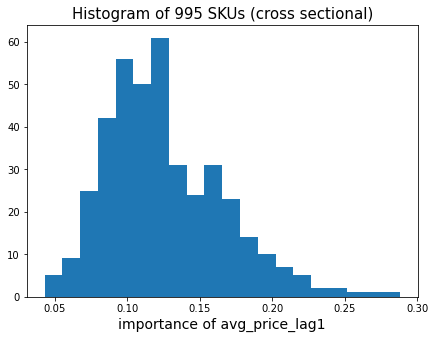

In [71]:
plt.figure(figsize=(7,5))
plt.hist(price_imp,bins=20)
plt.xlabel('importance of avg_price_lag1',fontsize=14)
plt.title('Histogram of 995 SKUs (cross sectional)',fontsize=15)
plt.show()

## R2 of in-sample & out-of-sample

In [72]:
df_ebm_oov[['r2_i','r2_o']]

,r2_i,r2_o
0,0.72,0.17
1,0.82,0.1
2,0.76,-0.03
3,0.64,-0.06
4,0.35,0.0
...,...,...
395,0.54,0.35
396,0.73,0.3
397,0.69,0.11
398,0.82,-0.03


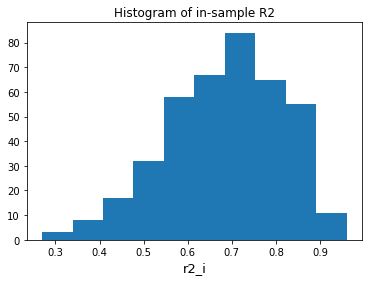

In [73]:
plt.hist(df_ebm_oov.r2_i)
plt.xlabel('r2_i',fontsize=13)
plt.title('Histogram of in-sample R2')
plt.show()

In [74]:
print('mean \t: ',df_ebm_oov.r2_i.mean().round(3), '\n',
      'var  \t: ',df_ebm_oov.r2_i.var().round(3), '\n')

mean 	:  0.685 
 var  	:  0.017 



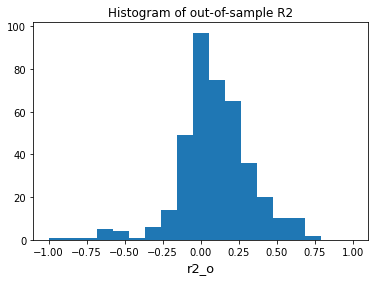

In [75]:
plt.hist(df_ebm_oov.r2_o,bins=np.linspace(-1,1,20))
plt.xlabel('r2_o',fontsize=13)
plt.title('Histogram of out-of-sample R2')
plt.show()

In [76]:
print('mean \t: ',df_ebm_oov.r2_o.mean().round(3), '\n',
      'var  \t: ',df_ebm_oov.r2_o.var().round(3), '\n')

mean 	:  0.079 
 var  	:  0.074 



## R2 diff

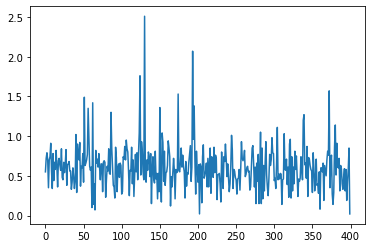

In [77]:
df_ebm_oov['r2_diff'] = df_ebm_oov.r2_i-df_ebm_oov.r2_o
df_ebm_oov.r2_diff.plot()
plt.show()

In [78]:
# SKUs with big negative R2
sum(df_ebm_oov.r2_o < 0)

133

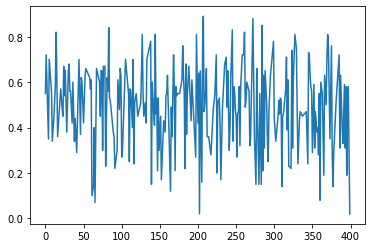

In [79]:
# Excluding that, but shows big difference
df_ebm_oov[df_ebm_oov.r2_o >= 0]['r2_diff'].plot()
plt.show()

In [80]:
df_ebm_oov[df_ebm_oov.r2_o >= 0]['r2_diff']

0      0.55
1      0.72
4      0.35
5       0.7
8      0.56
       ... 
394    0.58
395    0.19
396    0.43
397    0.58
399    0.02
Name: r2_diff, Length: 267, dtype: object

In [81]:
print('mean \t: ',df_ebm_oov[df_ebm_oov.r2_o >= 0]['r2_diff'].mean().round(3), '\n',
      'var  \t: ',df_ebm_oov[df_ebm_oov.r2_o >= 0]['r2_diff'].var().round(3), '\n')

mean 	:  0.493 
 var  	:  0.033 



In [82]:
sum(np.abs(df_ebm_oov.r2_diff)<=0.1)

5

In [83]:
127/979

0.12972420837589377

In [84]:
skus_r2diff_lt_10 = df_ebm_oov[np.abs(df_ebm_oov.r2_diff)<=0.1].sku
skus_r2diff_lt_10

61       FRBX-9GR-F
65     OLB-SSBFH-7F
202    AZ-GTFT-400T
360    OLB-MGT-400F
399      MSHEBT-13K
Name: sku, dtype: object

### SKU with huge difference 

In [85]:
idx = np.argmax(df_ebm_oov[df_ebm_oov.r2_o < 0]['r2_diff'])
df_ebm_oov[df_ebm_oov.r2_o < 0].iloc[idx]

sku                                                AZ-HBBS-75Q
rmse_i                                                14169.79
mape_i                                                   42.98
r2_i                                                      0.89
rmse_o                                                24605.24
mape_o                                                   58.21
r2_o                                                     -1.62
imp95        {'cnvrsn_rate_lag1': 0.146, 'ord_rev_lag1': 0....
ebm_model    ExplainableBoostingRegressor(feature_names=['o...
r2_diff                                                   2.51
Name: 130, dtype: object

In [86]:
df_set[df_set.sku=='AZ-HBBS-75Q'].ord_rev

0      11947.17
1      12846.04
2       7679.81
3       7608.17
4       8329.30
         ...   
130    12663.90
131     3813.90
132     2947.88
133     5406.66
134     7228.07
Name: ord_rev, Length: 135, dtype: float64

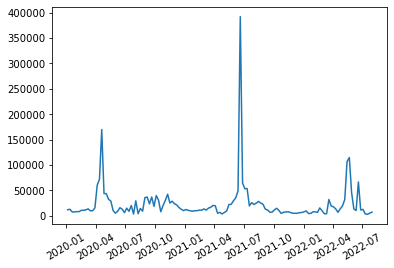

In [87]:
df_HugeDiff = df_set[df_set.sku=='AZ-HBBS-75Q']
plt.plot(df_HugeDiff.year_week,df_HugeDiff.ord_rev)
plt.xticks(rotation=30)
plt.show()

In [88]:
sum(df_set[df_set.sku=='AZ-HBBS-75Q'].ord_rev==0.0)

0

In [116]:
df_HugeDiff[['year_week','ord_rev']].sort_values('ord_rev',ascending=False)

,year_week,ord_rev
21,2020-05-31,8330.00
15,2020-04-19,8205.88
16,2020-04-26,8090.77
17,2020-05-03,8090.77
19,2020-05-17,7646.00
...,...,...
114,2022-03-13,350.00
113,2022-03-06,350.00
111,2022-02-20,349.36
122,2022-05-08,283.90


### SKU with slight difference 

In [109]:
idx = np.argmax(df_ebm_oov['r2_diff'])
df_ebm_oov.iloc[idx]

sku                                                AZ-HBBS-75Q
rmse_i                                                14169.79
mape_i                                                   42.98
r2_i                                                      0.89
rmse_o                                                24605.24
mape_o                                                   58.21
r2_o                                                     -1.62
imp95        {'cnvrsn_rate_lag1': 0.146, 'ord_rev_lag1': 0....
ebm_model    ExplainableBoostingRegressor(feature_names=['o...
r2_diff                                                   2.51
Name: 130, dtype: object

In [110]:
df_set[df_set.sku=='AZ-HBBS-75Q'].ord_rev

0      11947.17
1      12846.04
2       7679.81
3       7608.17
4       8329.30
         ...   
130    12663.90
131     3813.90
132     2947.88
133     5406.66
134     7228.07
Name: ord_rev, Length: 135, dtype: float64

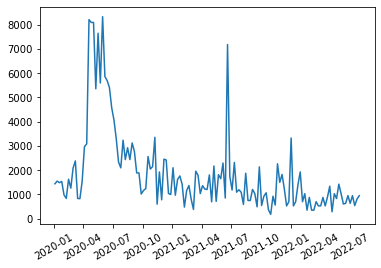

In [111]:
df_SlightDiff = df_set[df_set.sku=='AZ-HBBS-75Q']
plt.plot(df_SlightDiff.year_week,df_HugeDiff.ord_rev)
plt.xticks(rotation=30)
plt.show()

In [112]:
sum(df_set[df_set.sku=='AZ-HBBS-75Q'].ord_rev==0.0)

0

In [117]:
df_SlightDiff[['year_week','ord_rev']].sort_values('ord_rev',ascending=False)

,year_week,ord_rev
76,2021-06-20,391998.10
15,2020-04-19,169751.98
124,2022-05-22,114691.26
123,2022-05-15,106694.79
14,2020-04-12,71921.00
...,...,...
31,2020-08-09,4100.19
131,2022-07-10,3813.90
68,2021-04-25,3686.00
29,2020-07-26,3441.82


# OOVT (Out of Sample Validation : Time-aware) performance

In [89]:
perf_cols_new = ['sku','rmse_i','mape_i','r2_i','rmse_o','mape_o','r2_o','imp95','ebm_model']
df_ebm_oovt = pd.DataFrame(columns= perf_cols_new,index=range(len(SKUs)))

tSize = 24 # approx. 6 month
    
for k,sku in enumerate(SKUs):
    print('Working %d/%d...' % ((k+1),len(SKUs)), end='\r')
    tmp_df_set = df_set[df_set.sku==sku]
    tmp_df_set.set_index('year_week',inplace=True)

    X = tmp_df_set[features]
    y = tmp_df_set.ord_rev

    # Time-series like

    X_train=X.iloc[:-tSize,]
    X_test=X.iloc[-tSize:,]
    y_train=y.iloc[:-tSize]
    y_test=y.iloc[-tSize:]
    
    ebm = ExplainableBoostingRegressor(random_state=seed)
    ebm.fit(X_train, y_train)
    
    # Metrics for training set (100%)
    rmse_i,mape_i,r2_i = metrics_time_series(y_train,pd.Series(ebm.predict(X_train),\
                                                               index=X_train.index),verbose=False)
    rmse_o,mape_o,r2_o = metrics_time_series(y_test,pd.Series(ebm.predict(X_test),\
                                                               index=X_test.index),verbose=False)
    
    # Feature importance
    df_imp = pd.DataFrame(np.round(ebm.feature_importances_,0),\
             index=ebm.feature_names,columns=['importance']).sort_values(by='importance',ascending=False)
    df_imp_cum = (df_imp/df_imp.sum()).round(3).cumsum()
    df_imp95_raw = df_imp[df_imp_cum.importance<0.95]
    imp95 = (df_imp95_raw/df_imp95_raw.sum()).round(3).to_dict()['importance']
    
    df_ebm_oovt.loc[k] = {'sku':sku,
                         'rmse_i':rmse_i,
                         'mape_i':mape_i,
                         'r2_i':r2_i,
                         'rmse_o':rmse_o,
                         'mape_o':mape_o,
                         'r2_o':r2_o,
                         'imp95':imp95,
                         'ebm_model':ebm}

## Price is a predictor?

In [90]:
price_imp = [x['avg_price_lag1'] for x in df_ebm_oovt.imp95 if 'avg_price_lag1' in x.keys()]
price_imp

[0.107,
 0.089,
 0.124,
 0.12,
 0.073,
 0.109,
 0.08,
 0.14,
 0.076,
 0.112,
 0.136,
 0.086,
 0.084,
 0.09,
 0.096,
 0.18,
 0.104,
 0.057,
 0.158,
 0.098,
 0.106,
 0.096,
 0.099,
 0.183,
 0.239,
 0.069,
 0.09,
 0.093,
 0.113,
 0.118,
 0.228,
 0.065,
 0.121,
 0.132,
 0.096,
 0.145,
 0.183,
 0.08,
 0.203,
 0.08,
 0.12,
 0.116,
 0.154,
 0.111,
 0.114,
 0.136,
 0.174,
 0.119,
 0.132,
 0.108,
 0.076,
 0.105,
 0.084,
 0.145,
 0.052,
 0.113,
 0.081,
 0.132,
 0.096,
 0.135,
 0.139,
 0.139,
 0.093,
 0.16,
 0.105,
 0.153,
 0.12,
 0.149,
 0.152,
 0.153,
 0.093,
 0.118,
 0.104,
 0.068,
 0.076,
 0.2,
 0.084,
 0.168,
 0.164,
 0.11,
 0.062,
 0.148,
 0.108,
 0.203,
 0.117,
 0.209,
 0.143,
 0.114,
 0.087,
 0.099,
 0.124,
 0.135,
 0.117,
 0.157,
 0.206,
 0.104,
 0.092,
 0.105,
 0.141,
 0.158,
 0.141,
 0.127,
 0.12,
 0.1,
 0.11,
 0.082,
 0.089,
 0.127,
 0.096,
 0.138,
 0.091,
 0.139,
 0.077,
 0.138,
 0.085,
 0.105,
 0.198,
 0.067,
 0.086,
 0.202,
 0.164,
 0.069,
 0.093,
 0.157,
 0.106,
 0.113,
 0.113,
 0

### Most of the SKU has `avg_price` as a predictor

In [91]:
len(price_imp)

400

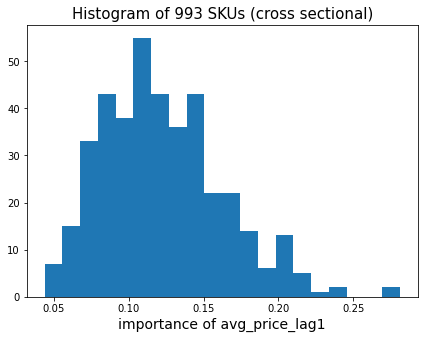

In [92]:
plt.figure(figsize=(7,5))
plt.hist(price_imp,bins=20)
plt.xlabel('importance of avg_price_lag1',fontsize=14)
plt.title('Histogram of 993 SKUs (cross sectional)',fontsize=15)
plt.show()

## R2 of in-sample & out-of-sample

In [93]:
df_ebm_oovt[['r2_i','r2_o']]

,r2_i,r2_o
0,0.57,0.18
1,0.71,0.09
2,0.51,0.03
3,0.62,-0.0
4,0.46,-0.11
...,...,...
395,0.41,-2.13
396,0.76,0.39
397,0.52,-0.06
398,0.56,-0.19


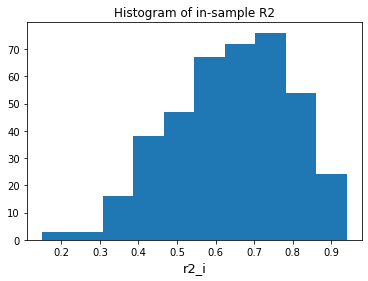

In [94]:
plt.hist(df_ebm_oovt.r2_i)
plt.xlabel('r2_i',fontsize=13)
plt.title('Histogram of in-sample R2')
plt.show()

In [95]:
print('mean \t: ',df_ebm_oovt.r2_i.mean().round(3), '\n',
      'var  \t: ',df_ebm_oovt.r2_i.var().round(3), '\n')

mean 	:  0.642 
 var  	:  0.024 



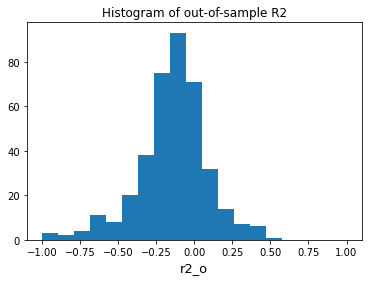

In [96]:
plt.hist(df_ebm_oovt.r2_o,bins=np.linspace(-1,1,20))
plt.xlabel('r2_o',fontsize=13)
plt.title('Histogram of out-of-sample R2')
plt.show()

In [97]:
print('mean \t: ',df_ebm_oovt.r2_o.mean().round(3), '\n',
      'var  \t: ',df_ebm_oovt.r2_o.var().round(3), '\n')

mean 	:  -0.201 
 var  	:  0.17 



## R2 diff

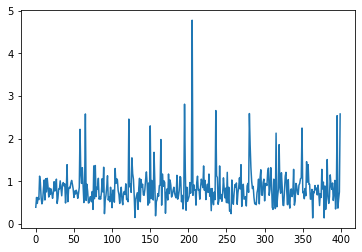

In [98]:
df_ebm_oovt['r2_diff'] = df_ebm_oovt.r2_i-df_ebm_oovt.r2_o
df_ebm_oovt.r2_diff.plot()
plt.show()

In [99]:
# SKUs with big negative R2
sum(df_ebm_oovt.r2_o <= 0)

320

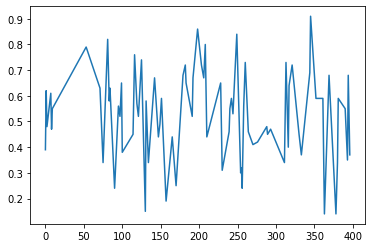

In [100]:
# Excluding that, but shows big difference
df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff'].plot()
plt.show()

In [101]:
df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff']

0      0.39
1      0.62
2      0.48
7      0.61
8      0.47
       ... 
381    0.59
390    0.55
393    0.35
394    0.68
396    0.37
Name: r2_diff, Length: 80, dtype: object

In [102]:
print('mean \t: ',df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff'].mean().round(3), '\n',
      'var  \t: ',df_ebm_oovt[df_ebm_oovt.r2_o > 0]['r2_diff'].var().round(3), '\n')

mean 	:  0.528 
 var  	:  0.031 



In [103]:
sum(np.abs(df_ebm_oovt.r2_diff)<0.1)

0

In [104]:
skus_Tr2diff_lt_10 = df_ebm_oovt[np.abs(df_ebm_oovt.r2_diff)<0.1].sku
skus_Tr2diff_lt_10

Series([], Name: sku, dtype: object)

### SKU with huge difference 

In [105]:
idx = np.argmax(df_ebm_oovt[df_ebm_oovt.r2_o < 0]['r2_diff'])
df_ebm_oovt[df_ebm_oovt.r2_o < 0].iloc[idx]

sku                                               OLB-SSBFH-7T
rmse_i                                                  660.77
mape_i                                                   32.28
r2_i                                                      0.87
rmse_o                                                   651.8
mape_o                                                  101.78
r2_o                                                     -3.91
imp95        {'gv_lag1': 0.229, 'ord_rev_lag1': 0.189, 'avg...
ebm_model    ExplainableBoostingRegressor(feature_names=['o...
r2_diff                                                   4.78
Name: 205, dtype: object

In [106]:
df_set[df_set.sku=='OLB-SSBFH-7T'].ord_rev

0      1437.08
1      1548.00
2      1483.21
3      1534.72
4       980.73
        ...   
130     632.00
131     948.00
132     538.40
133     807.60
134     948.00
Name: ord_rev, Length: 135, dtype: float64

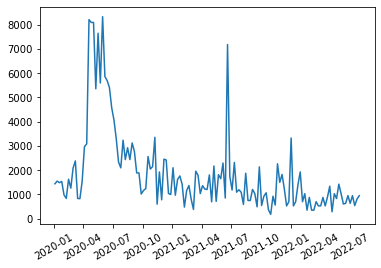

In [107]:
df_HugeDiff = df_set[df_set.sku=='OLB-SSBFH-7T']
plt.plot(df_HugeDiff.year_week,df_HugeDiff.ord_rev)
plt.xticks(rotation=30)
plt.show()

In [108]:
sum(df_set[df_set.sku=='OLB-SSBFH-7T'].ord_rev==0.0)

0

# Save performance files

In [114]:
df_ebm_oov.to_pickle('df_ebm_oov_lag_target.pickle')
df_ebm_oovt.to_pickle('df_ebm.oovt_lag_target.pickle')